In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import string
import squarify
pd.options.mode.chained_assignment = None

In [3]:
Sentiments=pd.read_csv('sentiment_tweet.csv')
Sentiments

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,569587686496825344,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,569587371693355008,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN
14637,569587242672398336,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN
14638,569587188687634433,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada)


In [4]:
Sentiments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [5]:
Sentiments.describe()

,tweet_id,airline_sentiment_confidence,negativereason_confidence,retweet_count
count,1.464000e+04,14640.000000,10522.000000,14640.000000
mean,5.692184e+17,0.900169,0.638298,0.082650
std,7.791112e+14,0.162830,0.330440,0.745778
min,5.675883e+17,0.335000,0.000000,0.000000
25%,5.685592e+17,0.692300,0.360600,0.000000
50%,5.694779e+17,1.000000,0.670600,0.000000
75%,5.698905e+17,1.000000,1.000000,0.000000
max,5.703106e+17,1.000000,1.000000,44.000000


In [6]:
x=Sentiments.isnull().sum()

In [7]:
y=(Sentiments.isnull().sum()/len(Sentiments))*100

In [8]:
Sent=pd.concat([x,y],axis=1)
Sent.rename(columns={0:'Missing',1:'Percentage_missing'})


,Missing,Percentage_missing
tweet_id,0,0.000000
airline_sentiment,0,0.000000
airline_sentiment_confidence,0,0.000000
negativereason,5462,37.308743
negativereason_confidence,4118,28.128415
airline,0,0.000000
airline_sentiment_gold,14600,99.726776
name,0,0.000000
negativereason_gold,14608,99.781421
retweet_count,0,0.000000


In [9]:
Sent=pd.concat([x,y],axis=1)
missings_cols=Sent.rename(columns={0:'Missing',1:'Percentage_missing'})
missings_cols = missings_cols[missings_cols.iloc[:,1]!=0].sort_values('Percentage_missing', ascending = False).round(2)
missings_cols

,Missing,Percentage_missing
negativereason_gold,14608,99.78
airline_sentiment_gold,14600,99.73
tweet_coord,13621,93.04
negativereason,5462,37.31
user_timezone,4820,32.92
tweet_location,4733,32.33
negativereason_confidence,4118,28.13


In [10]:
Sentiments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [11]:
Sentiments.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

In [12]:
import seaborn as sb

In [13]:
import matplotlib.pyplot as plt 

C:\Users\user\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


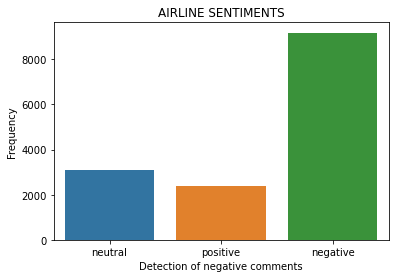

In [14]:
sb.countplot('airline_sentiment', data=Sentiments);
plt.title('AIRLINE SENTIMENTS')
plt.xlabel('Detection of negative comments')
plt.ylabel('Frequency')
plt.show()

In [15]:
# explore
plot_size=plt.rcParams['figure.figsize']
print(plot_size[0])
print(plot_size[1])

plot_size[0]=8
plot_size[1]=6
plt.rcParams['figure.figsize']=plot_size


6.0
4.0


<AxesSubplot:ylabel='airline'>

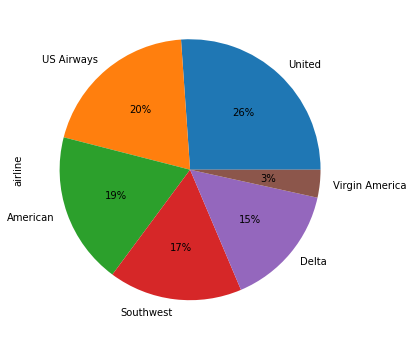

In [16]:
Sentiments.airline.value_counts().plot(kind='pie',autopct='%1.0f%%')

<AxesSubplot:ylabel='airline_sentiment'>

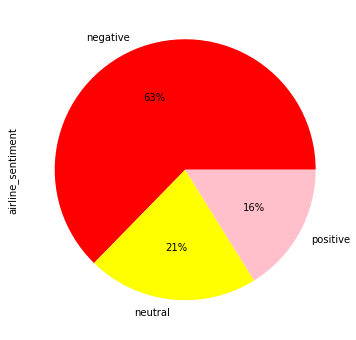

In [17]:
Sentiments.airline_sentiment.value_counts().plot(kind='pie',autopct='%1.0f%%',colors=['red','yellow','pink'])

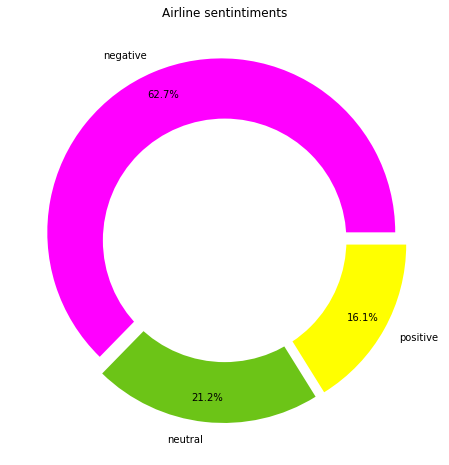

In [18]:
rates = Sentiments.airline_sentiment.value_counts()
labels = rates.index
  
# Setting size in Chart based on 
# given values
rate_counts = rates.values
  
# colors
colors = ['#FF00FF', '#6CC417', '#FFFF00']
# explosion
explode = (0.05, 0.05, 0.05)
  
# Pie Chart
plt.figure(figsize=(10, 8))
plt.pie(rate_counts, colors=colors, labels=labels,
        autopct='%1.1f%%', pctdistance=0.86,
        explode=explode)
  
# draw circle
centre_circle = plt.Circle((0, 0), 0.7, fc='white')
fig = plt.gcf()
  
# Adding Circle in Pie chart
fig.gca().add_artist(centre_circle)
  
# Adding Title of chart
plt.title('Airline sentintiments')
  
# Displaying Chart
plt.show()

<AxesSubplot:xlabel='airline'>

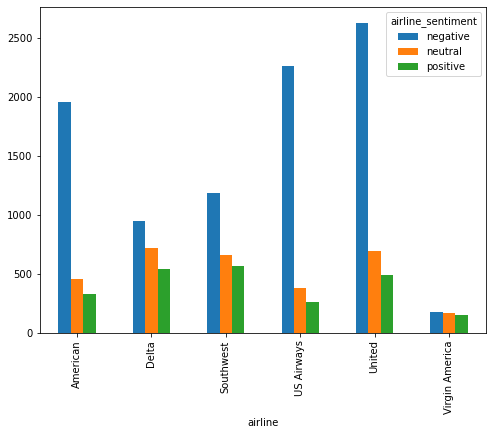

In [19]:
airline_sentiment=Sentiments.groupby(['airline','airline_sentiment']).airline_sentiment.count().unstack()
airline_sentiment.plot(kind='bar')

<AxesSubplot:xlabel='airline_sentiment', ylabel='airline_sentiment_confidence'>

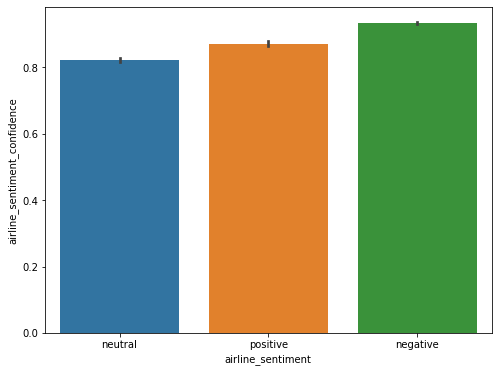

In [20]:
import seaborn as sb
sb.barplot(x='airline_sentiment',y='airline_sentiment_confidence',data=Sentiments)

In [21]:
from wordcloud import WordCloud

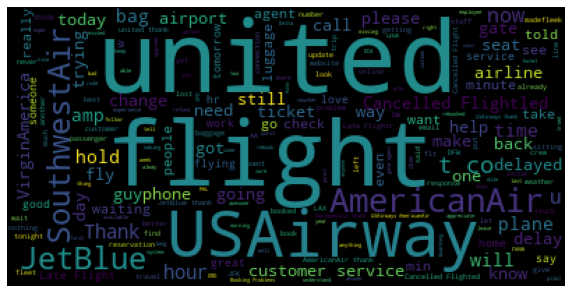

In [22]:
text3 = ' '.join(Sentiments['text'])
wordcloud2 = WordCloud().generate(text3)
# Generate plot
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud2)
plt.axis("off")
plt.show()

In [23]:
Sentiments['airline_sentiment'].unique()

array(['neutral', 'positive', 'negative'], dtype=object)

In [24]:
Sentiments[Sentiments['airline_sentiment']=='positive']

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
1,570301130888122368,positive,0.3486,NaN,0.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
6,570300616901320704,positive,0.6745,NaN,0.0,Virgin America,NaN,cjmcginnis,NaN,0,"@VirginAmerica yes, nearly every time I fly VX...",NaN,2015-02-24 11:13:57 -0800,San Francisco CA,Pacific Time (US & Canada)
8,570299953286942721,positive,0.6559,NaN,NaN,Virgin America,NaN,dhepburn,NaN,0,"@virginamerica Well, I didn't…but NOW I DO! :-D",NaN,2015-02-24 11:11:19 -0800,San Diego,Pacific Time (US & Canada)
9,570295459631263746,positive,1.0000,NaN,NaN,Virgin America,NaN,YupitsTate,NaN,0,"@VirginAmerica it was amazing, and arrived an ...",NaN,2015-02-24 10:53:27 -0800,Los Angeles,Eastern Time (US & Canada)
11,570289724453216256,positive,1.0000,NaN,NaN,Virgin America,NaN,HyperCamiLax,NaN,0,@VirginAmerica I &lt;3 pretty graphics. so muc...,NaN,2015-02-24 10:30:40 -0800,NYC,America/New_York
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14623,569590013278756865,positive,0.6274,NaN,0.0,American,NaN,Flora_Lola_NYC,NaN,0,@AmericanAir Love the new planes for the JFK-L...,NaN,2015-02-22 12:10:16 -0800,NaN,Eastern Time (US & Canada)
14625,569589643487928321,positive,1.0000,NaN,NaN,American,NaN,DrCaseyJRudkin,NaN,0,@AmericanAir Flight 236 was great. Fantastic c...,"[40.64946781, -73.76624703]",2015-02-22 12:08:48 -0800,East Coast,NaN
14628,569588651925098496,positive,1.0000,NaN,NaN,American,NaN,jlhalldc,NaN,0,Thank you. “@AmericanAir: @jlhalldc Customer R...,NaN,2015-02-22 12:04:51 -0800,"Washington, DC",Eastern Time (US & Canada)
14630,569588473050611712,positive,1.0000,NaN,NaN,American,NaN,Laurelinesblog,NaN,0,@AmericanAir Thanks! He is.,NaN,2015-02-22 12:04:09 -0800,"Chapel Hill, NC",NaN


### wordcloud For Positive Sentiment

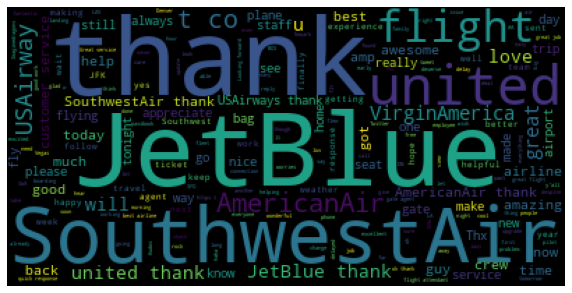

In [25]:
text3 = ' '.join(Sentiments[Sentiments['airline_sentiment']=='positive'].text)
wordcloud2 = WordCloud().generate(text3)
# Generate plot
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud2)
plt.axis("off")
plt.show()

In [26]:
#Negative

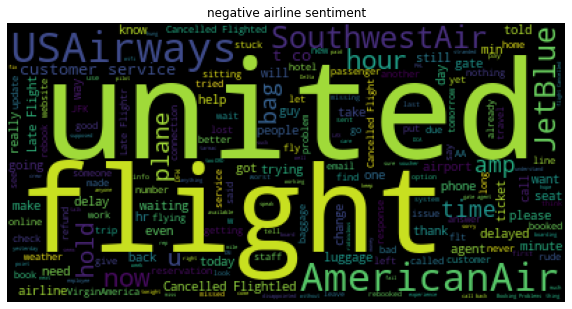

In [27]:
text3 = ' '.join(Sentiments[Sentiments['airline_sentiment']=='negative'].text)
wordcloud2 = WordCloud().generate(text3)
# Generate plot
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud2)
plt.axis("off")
plt.title('negative airline sentiment')
plt.show()

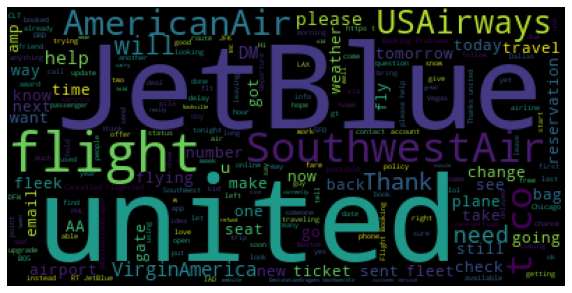

In [28]:
text3 = ' '.join(Sentiments[Sentiments['airline_sentiment']=='neutral'].text)
wordcloud2 = WordCloud().generate(text3)
# Generate plot
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud2)
plt.axis("off")
plt.show()

In [29]:
detection=Sentiments['airline_sentiment'].value_counts()

In [30]:
duplicated_values =Sentiments.duplicated().sum()#Checking duplicates
duplicated_values

36

In [31]:
data_ITEM_IDENT_NM = Sentiments.groupby('text')['airline_sentiment_confidence'].count().reset_index(name='counts')
data_ITEM_IDENT_NM.iloc[:6]

,text,counts
0,"""LOL you guys are so on it"" - me, had this bee...",1
1,#Real RT @JetBlue: Our fleet's on fleek. http:...,1
2,#nothelpful MT @AmericanAir: Our call volume i...,1
3,&lt;3 &lt;3 RT @SouthwestAir! @danihampton Sor...,1
4,*On the brink of bankruptcy. “@JetBlue: Our fl...,1
5,",@USAirways 2nd time this occurred in 3 weeks....",1


<AxesSubplot:title={'center':'The features the airlines sentiments'}>

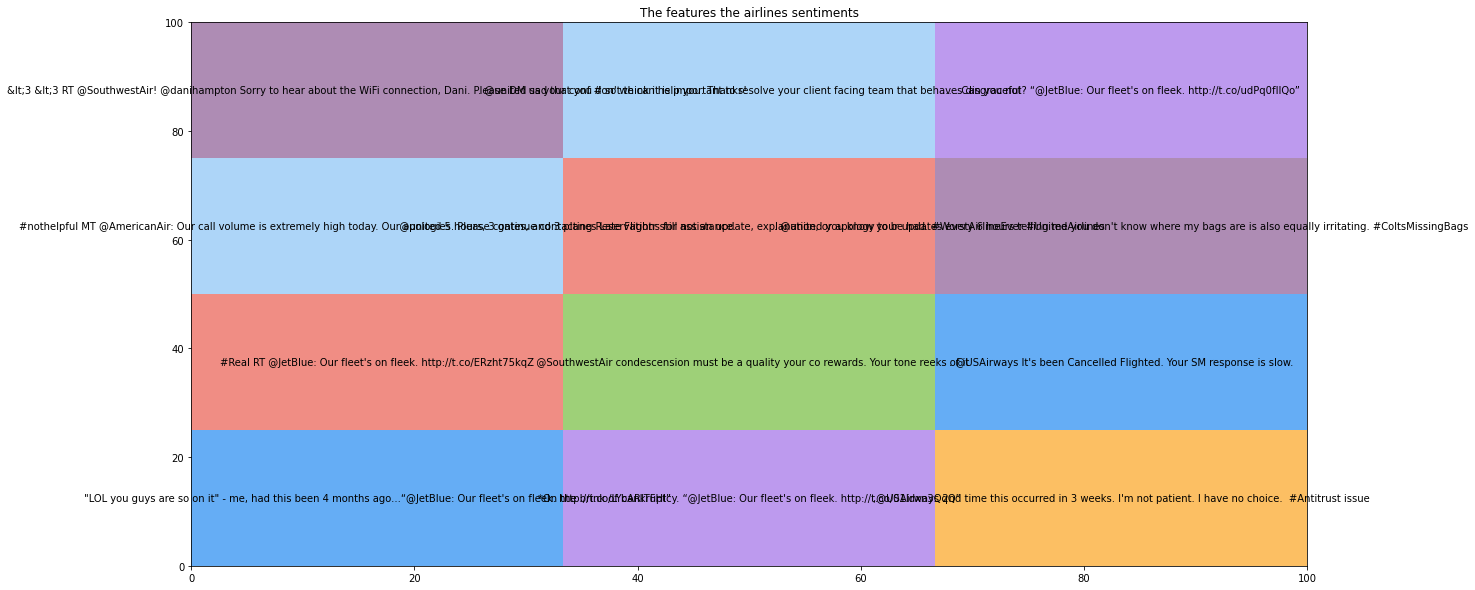

In [32]:
# for visualization
segment = list(data_ITEM_IDENT_NM.iloc[:12].text)
score = list(data_ITEM_IDENT_NM.iloc[:12].counts)
color_list = ["#248af1", "#eb5d50", "#8bc4f6", "#8c5c94", "#a170e8", "#fba521", "#75bc3f"]
plt.figure(figsize=(20,10))
plt.title('The features the airlines sentiments')
squarify.plot(sizes=score, label=segment,color=color_list, alpha=0.7)


In [33]:
Sentiments.drop_duplicates()# Dropping duplicates
Sentiments

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,569587686496825344,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,569587371693355008,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN
14637,569587242672398336,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN
14638,569587188687634433,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada)


In [34]:
Sentiments2=Sentiments.applymap(lambda x: x.lower() if type(x)==str else x)
Sentiments2#Lowering the case for all characters

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,virgin america,NaN,cairdin,NaN,0,@virginamerica what @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,eastern time (us & canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,virgin america,NaN,jnardino,NaN,0,@virginamerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,pacific time (us & canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,virgin america,NaN,yvonnalynn,NaN,0,@virginamerica i didn't today... must mean i n...,NaN,2015-02-24 11:15:48 -0800,lets play,central time (us & canada)
3,570301031407624196,negative,1.0000,bad flight,0.7033,virgin america,NaN,jnardino,NaN,0,@virginamerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,pacific time (us & canada)
4,570300817074462722,negative,1.0000,can't tell,1.0000,virgin america,NaN,jnardino,NaN,0,@virginamerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,pacific time (us & canada)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,569587686496825344,positive,0.3487,NaN,0.0000,american,NaN,kristenreenders,NaN,0,@americanair thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,569587371693355008,negative,1.0000,customer service issue,1.0000,american,NaN,itsropes,NaN,0,@americanair leaving over 20 minutes late flig...,NaN,2015-02-22 11:59:46 -0800,texas,NaN
14637,569587242672398336,neutral,1.0000,NaN,NaN,american,NaN,sanyabun,NaN,0,@americanair please bring american airlines to...,NaN,2015-02-22 11:59:15 -0800,"nigeria,lagos",NaN
14638,569587188687634433,negative,1.0000,customer service issue,0.6659,american,NaN,srajackson,NaN,0,"@americanair you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,new jersey,eastern time (us & canada)


In [35]:
Sentiments2.head(10)

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,virgin america,NaN,cairdin,NaN,0,@virginamerica what @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,eastern time (us & canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,virgin america,NaN,jnardino,NaN,0,@virginamerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,pacific time (us & canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,virgin america,NaN,yvonnalynn,NaN,0,@virginamerica i didn't today... must mean i n...,NaN,2015-02-24 11:15:48 -0800,lets play,central time (us & canada)
3,570301031407624196,negative,1.0000,bad flight,0.7033,virgin america,NaN,jnardino,NaN,0,@virginamerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,pacific time (us & canada)
4,570300817074462722,negative,1.0000,can't tell,1.0000,virgin america,NaN,jnardino,NaN,0,@virginamerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,pacific time (us & canada)
5,570300767074181121,negative,1.0000,can't tell,0.6842,virgin america,NaN,jnardino,NaN,0,@virginamerica seriously would pay $30 a fligh...,NaN,2015-02-24 11:14:33 -0800,NaN,pacific time (us & canada)
6,570300616901320704,positive,0.6745,NaN,0.0000,virgin america,NaN,cjmcginnis,NaN,0,"@virginamerica yes, nearly every time i fly vx...",NaN,2015-02-24 11:13:57 -0800,san francisco ca,pacific time (us & canada)
7,570300248553349120,neutral,0.6340,NaN,NaN,virgin america,NaN,pilot,NaN,0,@virginamerica really missed a prime opportuni...,NaN,2015-02-24 11:12:29 -0800,los angeles,pacific time (us & canada)
8,570299953286942721,positive,0.6559,NaN,NaN,virgin america,NaN,dhepburn,NaN,0,"@virginamerica well, i didn't…but now i do! :-d",NaN,2015-02-24 11:11:19 -0800,san diego,pacific time (us & canada)
9,570295459631263746,positive,1.0000,NaN,NaN,virgin america,NaN,yupitstate,NaN,0,"@virginamerica it was amazing, and arrived an ...",NaN,2015-02-24 10:53:27 -0800,los angeles,eastern time (us & canada)


In [36]:
exclude=set(string.punctuation)#set all special characters
#Removing all the special characters
Sentiments2['text']=Sentiments2['text'].apply(lambda x: "".join(ch for ch in x if ch not in exclude))


In [37]:
Sentiments2.head(20)

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,virgin america,NaN,cairdin,NaN,0,virginamerica what dhepburn said,NaN,2015-02-24 11:35:52 -0800,NaN,eastern time (us & canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,virgin america,NaN,jnardino,NaN,0,virginamerica plus youve added commercials to ...,NaN,2015-02-24 11:15:59 -0800,NaN,pacific time (us & canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,virgin america,NaN,yvonnalynn,NaN,0,virginamerica i didnt today must mean i need t...,NaN,2015-02-24 11:15:48 -0800,lets play,central time (us & canada)
3,570301031407624196,negative,1.0000,bad flight,0.7033,virgin america,NaN,jnardino,NaN,0,virginamerica its really aggressive to blast o...,NaN,2015-02-24 11:15:36 -0800,NaN,pacific time (us & canada)
4,570300817074462722,negative,1.0000,can't tell,1.0000,virgin america,NaN,jnardino,NaN,0,virginamerica and its a really big bad thing a...,NaN,2015-02-24 11:14:45 -0800,NaN,pacific time (us & canada)
5,570300767074181121,negative,1.0000,can't tell,0.6842,virgin america,NaN,jnardino,NaN,0,virginamerica seriously would pay 30 a flight ...,NaN,2015-02-24 11:14:33 -0800,NaN,pacific time (us & canada)
6,570300616901320704,positive,0.6745,NaN,0.0000,virgin america,NaN,cjmcginnis,NaN,0,virginamerica yes nearly every time i fly vx t...,NaN,2015-02-24 11:13:57 -0800,san francisco ca,pacific time (us & canada)
7,570300248553349120,neutral,0.6340,NaN,NaN,virgin america,NaN,pilot,NaN,0,virginamerica really missed a prime opportunit...,NaN,2015-02-24 11:12:29 -0800,los angeles,pacific time (us & canada)
8,570299953286942721,positive,0.6559,NaN,NaN,virgin america,NaN,dhepburn,NaN,0,virginamerica well i didnt…but now i do d,NaN,2015-02-24 11:11:19 -0800,san diego,pacific time (us & canada)
9,570295459631263746,positive,1.0000,NaN,NaN,virgin america,NaN,yupitstate,NaN,0,virginamerica it was amazing and arrived an ho...,NaN,2015-02-24 10:53:27 -0800,los angeles,eastern time (us & canada)


In [38]:
sentiment_label =Sentiments2.text.factorize()
sentiment_label

(array([    0,     1,     2, ..., 14365, 14366, 14367], dtype=int64),
 Index(['virginamerica what dhepburn said',
        'virginamerica plus youve added commercials to the experience tacky',
        'virginamerica i didnt today must mean i need to take another trip',
        'virginamerica its really aggressive to blast obnoxious entertainment in your guests faces amp they have little recourse',
        'virginamerica and its a really big bad thing about it',
        'virginamerica seriously would pay 30 a flight for seats that didnt have this playing\nits really the only bad thing about flying va',
        'virginamerica yes nearly every time i fly vx this “ear worm” won’t go away ',
        'virginamerica really missed a prime opportunity for men without hats parody there httpstcomwpg7grezp',
        'virginamerica well i didnt…but now i do d',
        'virginamerica it was amazing and arrived an hour early youre too good to me',
        ...
        'americanair thanks he is',
     

In [39]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(Sentiments)

In [40]:
encoded_docs= tokenizer.texts_to_sequences(Sentiments)
encoded_docs

[[1, 7],
 [2, 3],
 [2, 3, 5],
 [4],
 [4, 5],
 [2],
 [2, 3, 6],
 [8],
 [4, 6],
 [9, 10],
 [11],
 [1, 12],
 [1, 13],
 [1, 14],
 [15, 16]]

In [41]:
Sentiments.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

In [42]:
x=Sentiments.drop(['airline_sentiment'],1)
y=Sentiments['airline_sentiment']  
x

,tweet_id,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,569587686496825344,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,569587371693355008,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN
14637,569587242672398336,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN
14638,569587188687634433,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada)


In [43]:
from sklearn.preprocessing import LabelEncoder

In [44]:
le=LabelEncoder()

In [45]:
# for j in Object:
#     Sentiments[j]=le.fit_transform(Sentiments[j].astype(str))
print(Sentiments.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [46]:
Sentiments.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

In [47]:
Sentiments['airline_sentiment']=le.fit_transform(Sentiments['airline_sentiment'])
Sentiments['airline_sentiment']

0        1
1        2
2        1
3        0
4        0
        ..
14635    2
14636    0
14637    1
14638    0
14639    1
Name: airline_sentiment, Length: 14640, dtype: int32

In [48]:
Sentiments['negativereason']=le.fit_transform(Sentiments['negativereason'])
Sentiments['negativereason']

0        10
1        10
2        10
3         0
4         1
         ..
14635    10
14636     3
14637    10
14638     3
14639    10
Name: negativereason, Length: 14640, dtype: int32

In [49]:
x=Sentiments.drop(['airline_sentiment'],1)
y=Sentiments['airline_sentiment']  
x

,tweet_id,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,1.0000,10,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,0.3486,10,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,0.6837,10,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,1.0000,0,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,1.0000,1,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,569587686496825344,0.3487,10,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,569587371693355008,1.0000,3,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN
14637,569587242672398336,1.0000,10,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN
14638,569587188687634433,1.0000,3,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada)


In [50]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import RegexpTokenizer

In [51]:
#tokenizer to remove unwanted elements from out data like symbols and numbers
tk = RegexpTokenizer(r'[a-zA-Z0-9]+')
cv = CountVectorizer(lowercase=True,stop_words='english',ngram_range = (1,1),tokenizer = tk.tokenize)
text_counts= cv.fit_transform(Sentiments['text'])

In [56]:
Sentiments.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
tfd=TfidfVectorizer()
tfdata=tfd.fit_transform(Sentiments['text'])

In [64]:
xtrain,xtest,ytrain, ytest=train_test_split(tfdata,Sentiments.airline_sentiment, test_size=0.1)

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier,ExtraTreesClassifier,GradientBoostingClassifier,RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [66]:
clfs = {
# 'LogisticRegression' : LogisticRegression(random_state=2),
'DecisionTreeClassifier': DecisionTreeClassifier(random_state=2),
'RandomForest': RandomForestClassifier(random_state=2),
'AdaBoost': AdaBoostClassifier(random_state=2),
'Etra Tree':ExtraTreesClassifier(random_state=2),
'GradientBoosting':GradientBoostingClassifier(random_state=2),
'KNN':KNeighborsClassifier( n_neighbors=4),
'Naive bayes':MultinomialNB()
}

In [67]:
#code block to test all models in clfs and generate a report
models_report = pd.DataFrame(columns = ['Model', 'Precision_score', 'Recall_score','F1_score','Accuracy'])

for clf, clf_name in zip(clfs.values(), clfs.keys()):
    clf.fit(xtrain,ytrain)
    y_pred = clf.predict(xtest)
    y_score = clf.score(xtest,ytest)
   
    #print('Calculating {}'.format(clf_name))
    t = pd.Series({
                     'Model': clf_name,
                     'Precision_score': metrics.precision_score(ytest, y_pred,average='macro'),
                     'Recall_score': metrics.recall_score(ytest, y_pred,average='macro'),
                     'F1_score': metrics.f1_score(ytest, y_pred,average='macro'),
#                      'AUC':metrics.roc_auc_score(ytest, y_pred),
                     'Accuracy': metrics.accuracy_score(ytest, y_pred)}
                     
                   )

    models_report = models_report.append(t, ignore_index = True)

models_report


,Model,Precision_score,Recall_score,F1_score,Accuracy
0,DecisionTreeClassifier,0.616174,0.610092,0.612854,0.693989
1,RandomForest,0.790801,0.605009,0.651252,0.760246
2,AdaBoost,0.690052,0.629718,0.651995,0.736339
3,Etra Tree,0.791352,0.609766,0.655083,0.762978
4,GradientBoosting,0.746799,0.605572,0.639351,0.746585
5,KNN,0.635314,0.613414,0.622216,0.713115
6,Naive bayes,0.787914,0.425939,0.425024,0.669399
